In [64]:
# INTRODUCTION

# This notebook builds a recommendation system using collaborative filtering.
# The goal is to recommend movies to users based on their ratings.
# User-item interactions are used to find similar users and preferences.
# The system predicts and suggests unseen movies for each user.

In [65]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from sklearn.metrics import mean_squared_error

In [66]:
# Recommendation System using Collaborative Filtering

# Loading the movie dataset
df = pd.read_csv("movie_ratings.csv")

In [67]:
# Display first few records for dataset preview
df.head(5)

,userId,movieId,rating,timestamp
0,1,31,2.5,1260759144
1,1,1029,3.0,1260759179
2,1,1061,3.0,1260759182
3,1,1129,2.0,1260759185
4,1,1172,4.0,1260759205


In [68]:
# Display last few records for dataset preview
df.tail(5)

,userId,movieId,rating,timestamp
99999,671,6268,2.5,1065579370
100000,671,6269,4.0,1065149201
100001,671,6365,4.0,1070940363
100002,671,6385,2.5,1070979663
100003,671,6565,3.5,1074784724


In [69]:
# Basic information about movie_ratings dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 4 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   userId     100004 non-null  int64  
 1   movieId    100004 non-null  int64  
 2   rating     100004 non-null  float64
 3   timestamp  100004 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 3.1 MB


In [70]:
# Statistical summary of data
df.describe()

,userId,movieId,rating,timestamp
count,100004.000000,100004.000000,100004.000000,1.000040e+05
mean,347.011310,12548.664363,3.543608,1.129639e+09
std,195.163838,26369.198969,1.058064,1.916858e+08
min,1.000000,1.000000,0.500000,7.896520e+08
25%,182.000000,1028.000000,3.000000,9.658478e+08
50%,367.000000,2406.500000,4.000000,1.110422e+09
75%,520.000000,5418.000000,4.000000,1.296192e+09
max,671.000000,163949.000000,5.000000,1.476641e+09


In [71]:
# Checking column names
print(df.columns)

Index(['userId', 'movieId', 'rating', 'timestamp'], dtype='object')


In [72]:
# Creating user-item matrix
user_item = df.pivot_table(index='userId', columns='movieId', values='rating')

# Viewing matrix
user_item.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,161084,161155,161594,161830,161918,161944,162376,162542,162672,163949
userId,,,,,,,,,,,,,,,,,,,,,
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [73]:
# Replace NaN with 0
user_item_filled = user_item.fillna(0)

In [74]:
# Again Viewing matrix with new name
user_item_filled.head(5)

movieId,1,2,3,4,5,6,7,8,9,10,...,161084,161155,161594,161830,161918,161944,162376,162542,162672,163949
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,4.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [75]:
# Computing similarity between users
user_similarity = cosine_similarity(user_item_filled)

# Converting to DataFrame
user_similarity_df = pd.DataFrame(user_similarity, index=user_item.index, columns=user_item.index)

user_similarity_df.head()

userId,1,2,3,4,5,6,7,8,9,10,...,662,663,664,665,666,667,668,669,670,671
userId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.000000,0.000000,0.074482,0.016818,0.000000,0.083884,0.000000,0.012843,0.000000,...,0.000000,0.000000,0.014474,0.043719,0.000000,0.000000,0.000000,0.062917,0.000000,0.017466
2,0.000000,1.000000,0.124295,0.118821,0.103646,0.000000,0.212985,0.113190,0.113333,0.043213,...,0.477306,0.063202,0.077745,0.164162,0.466281,0.425462,0.084646,0.024140,0.170595,0.113175
3,0.000000,0.124295,1.000000,0.081640,0.151531,0.060691,0.154714,0.249781,0.134475,0.114672,...,0.161205,0.064198,0.176134,0.158357,0.177098,0.124562,0.124911,0.080984,0.136606,0.170193
4,0.074482,0.118821,0.081640,1.000000,0.130649,0.079648,0.319745,0.191013,0.030417,0.137186,...,0.114319,0.047228,0.136579,0.254030,0.121905,0.088735,0.068483,0.104309,0.054512,0.211609
5,0.016818,0.103646,0.151531,0.130649,1.000000,0.063796,0.095888,0.165712,0.086616,0.032370,...,0.191029,0.021142,0.146173,0.224245,0.139721,0.058252,0.042926,0.038358,0.062642,0.225086


In [76]:
# Item-Based Collaborative Filtering

# Compute item similarity
item_similarity = cosine_similarity(user_item_filled.T)

item_similarity_df = pd.DataFrame(
    item_similarity,
    index=user_item.columns,
    columns=user_item.columns
)

item_similarity_df.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,161084,161155,161594,161830,161918,161944,162376,162542,162672,163949
movieId,,,,,,,,,,,,,,,,,,,,,
1,1.000000,0.394511,0.306516,0.133614,0.245102,0.377086,0.278629,0.063031,0.117499,0.310689,...,0.055829,0.031902,0.079755,0.079755,0.079755,0.079755,0.079755,0.0,0.0,0.055829
2,0.394511,1.000000,0.217492,0.164651,0.278476,0.222003,0.207299,0.223524,0.113669,0.418124,...,0.000000,0.055038,0.068797,0.082557,0.082557,0.137594,0.068797,0.0,0.0,0.000000
3,0.306516,0.217492,1.000000,0.177012,0.370732,0.247499,0.435648,0.127574,0.306717,0.191255,...,0.000000,0.000000,0.000000,0.116226,0.116226,0.000000,0.000000,0.0,0.0,0.000000
4,0.133614,0.164651,0.177012,1.000000,0.179556,0.072518,0.184626,0.501513,0.254630,0.111447,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.0,0.000000
5,0.245102,0.278476,0.370732,0.179556,1.000000,0.272645,0.388476,0.194113,0.367941,0.246846,...,0.000000,0.176845,0.000000,0.117897,0.117897,0.000000,0.000000,0.0,0.0,0.000000


In [77]:
# RECOMMENDATION FUNCTION

# Recommend movies for a user
def recommend_movies(user_id, top_n=5):
    
    # Get similar users
    similar_users = user_similarity_df[user_id].sort_values(ascending=False)[1:6]
    
    # Get movies watched by user
    user_movies = user_item.loc[user_id]
    watched = user_movies[user_movies > 0].index
    
    # Collect recommendations
    recommendations = {}
    
    for sim_user, score in similar_users.items():
        sim_user_movies = user_item.loc[sim_user]
        
        for movie, rating in sim_user_movies.items():
            if movie not in watched and rating > 0:
                if movie not in recommendations:
                    recommendations[movie] = 0
                recommendations[movie] += score * rating
    
    # Sort recommendations
    sorted_recommendations = sorted(recommendations.items(), key=lambda x: x[1], reverse=True)
    
    return [movie for movie, _ in sorted_recommendations[:top_n]]

In [78]:
# SHOWING RECOMMENDATION TO USERS

# Get recommendations for a user
user_id = 1
recommended_movies = recommend_movies(user_id)

print("Recommended Movies for User", user_id, ":", recommended_movies)

Recommended Movies for User 1 : [4085, 585, 1569, 256, 3039]


In [79]:
# Get movie recommendations for more three users
users = [1, 2, 3, 4]

for user_id in users:
    recs = recommend_movies(user_id)
    print(f"\nUser {user_id} Movie Recommendations:")
    
    for i, movie in enumerate(recs, 1):
        print(f"{i}. Movie ID: {movie}")


User 1 Movie Recommendations:
1. Movie ID: 4085
2. Movie ID: 585
3. Movie ID: 1569
4. Movie ID: 256
5. Movie ID: 3039

User 2 Movie Recommendations:
1. Movie ID: 318
2. Movie ID: 597
3. Movie ID: 21
4. Movie ID: 595
5. Movie ID: 344

User 3 Movie Recommendations:
1. Movie ID: 4306
2. Movie ID: 1
3. Movie ID: 3578
4. Movie ID: 4993
5. Movie ID: 3147

User 4 Movie Recommendations:
1. Movie ID: 2028
2. Movie ID: 1
3. Movie ID: 223
4. Movie ID: 953
5. Movie ID: 2355


In [80]:
# Test recommendations for multiple users
for uid in [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]:
    print(f"\nUser {uid} Recommendations:", recommend_movies(uid))


User 1 Recommendations: [4085, 585, 1569, 256, 3039]

User 2 Recommendations: [318, 597, 21, 595, 344]

User 3 Recommendations: [4306, 1, 3578, 4993, 3147]

User 4 Recommendations: [2028, 1, 223, 953, 2355]

User 5 Recommendations: [318, 110, 4886, 8961, 4993]

User 6 Recommendations: [1196, 4993, 318, 1198, 260]

User 7 Recommendations: [296, 1214, 1200, 457, 733]

User 8 Recommendations: [1682, 1, 4306, 6539, 1639]

User 9 Recommendations: [110, 50, 1210, 1610, 150]

User 10 Recommendations: [593, 589, 2028, 260, 110]


In [81]:
# ROOT MEAN SQUARED ERROR (RSME) EVALUATION

# Predict ratings using similarity
predicted_ratings = np.dot(user_similarity, user_item_filled) / np.array([np.abs(user_similarity).sum(axis=1)]).T

# Flatten actual and predicted
actual = user_item_filled.values.flatten()
predicted = predicted_ratings.flatten()

# Remove zero values
mask = actual > 0

rmse = np.sqrt(mean_squared_error(actual[mask], predicted[mask]))

print("RMSE:", rmse)

RMSE: 3.126236152132509


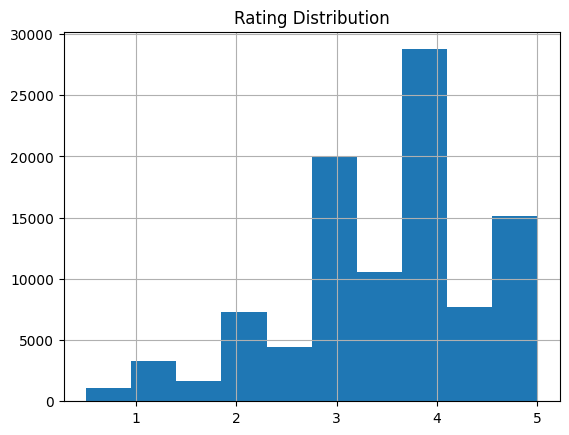

In [82]:
# Plotting rating distribution
df['rating'].hist()
plt.title("Rating Distribution")
plt.show()

In [83]:
# TOP ACTIVE USERS

# Top users by number of ratings
df['userId'].value_counts().head().rename_axis('userId').reset_index(name='rating_count')

,userId,rating_count
0,547,2391
1,564,1868
2,624,1735
3,15,1700
4,73,1610


In [84]:
# TOP RATED MOVIES

# Top movies by average rating
df.groupby('movieId')['rating'].mean().sort_values(ascending=False).head()

movieId
163949    5.0
71180     5.0
51471     5.0
52617     5.0
53887     5.0
Name: rating, dtype: float64

In [85]:
# Matrix Factorization (SVD)

# Applying SVD(Singular Value Decomposition)
from scipy.sparse.linalg import svds
import numpy as np

# Convert DataFrame to numpy array
matrix = user_item_filled.values

# Apply SVD
U, sigma, Vt = svds(matrix, k=20)

# Convert sigma to diagonal matrix
sigma = np.diag(sigma)

# Reconstruct predicted ratings matrix
svd_predictions = np.dot(np.dot(U, sigma), Vt)

In [86]:
# Item-based recommendation function
def recommend_items(user_id, top_n=5):
    
    user_ratings = user_item.loc[user_id]
    liked_movies = user_ratings[user_ratings > 3].index
    
    scores = {}
    
    for movie in liked_movies:
        similar_movies = item_similarity_df[movie].sort_values(ascending=False)[1:6]
        
        for sim_movie, score in similar_movies.items():
            if sim_movie not in liked_movies:
                if sim_movie not in scores:
                    scores[sim_movie] = 0
                scores[sim_movie] += score
    
    sorted_scores = sorted(scores.items(), key=lambda x: x[1], reverse=True)
    
    return [movie for movie, _ in sorted_scores[:top_n]]

In [87]:
# Recommend using SVD
def recommend_svd(user_id, top_n=5):
    
    user_row = user_id - 1
    user_pred = svd_predictions[user_row]
    
    sorted_indices = np.argsort(user_pred)[::-1]
    
    return sorted_indices[:top_n]

In [88]:
# Compare recommendation methods
print("User-based:", recommend_movies(1))
print("Item-based:", recommend_items(1))
print("SVD-based:", recommend_svd(1))

User-based: [4085, 585, 1569, 256, 3039]
Item-based: [2243, 2193, 3152, 2968, 2917]
SVD-based: [ 970 1114 1036 2380 1125]


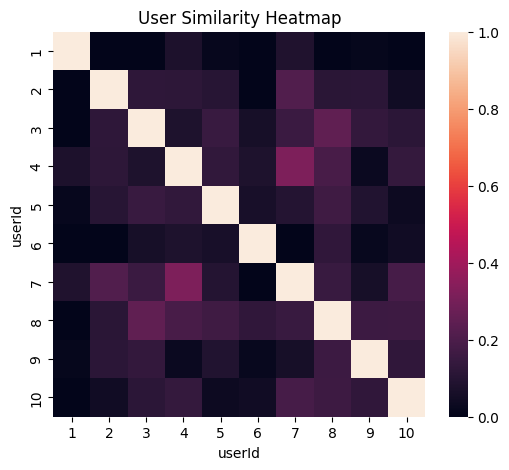

In [89]:
# Visualizing similarity heatmap
import seaborn as sns

plt.figure(figsize=(6,5))
sns.heatmap(user_similarity_df.iloc[:10, :10])
plt.title("User Similarity Heatmap")
plt.show()

In [90]:
# Recommendation Pipeline

# Simple recommendation pipeline
def recommendation_pipeline(user_id):
    return {
        "User-Based": recommend_movies(user_id),
        "Item-Based": recommend_items(user_id),
        "SVD-Based": recommend_svd(user_id)
    }

# Get results
results = recommendation_pipeline(1)

# Print each on a new line
for key, value in results.items():
    print(f"{key}:\n{value}\n")

User-Based:
[4085, 585, 1569, 256, 3039]

Item-Based:
[2243, 2193, 3152, 2968, 2917]

SVD-Based:
[ 970 1114 1036 2380 1125]



In [91]:
# Top N Users Testing

# Testing multiple users
for uid in range(1,11):
    print(f"\nUser {uid} →", recommendation_pipeline(uid))


User 1 → {'User-Based': [4085, 585, 1569, 256, 3039], 'Item-Based': [2243, 2193, 3152, 2968, 2917], 'SVD-Based': array([ 970, 1114, 1036, 2380, 1125], dtype=int64)}

User 2 → {'User-Based': [318, 597, 21, 595, 344], 'Item-Based': [380, 457, 356, 597, 593], 'SVD-Based': array([523, 129, 406, 266, 321], dtype=int64)}

User 3 → {'User-Based': [4306, 1, 3578, 4993, 3147], 'Item-Based': [2571, 593, 6711, 480, 50], 'SVD-Based': array([284, 321, 266, 525, 472], dtype=int64)}

User 4 → {'User-Based': [2028, 1, 223, 953, 2355], 'Item-Based': [2659, 380, 1394, 2915, 595], 'SVD-Based': array([953, 955, 966, 232, 954], dtype=int64)}

User 5 → {'User-Based': [318, 110, 4886, 8961, 4993], 'Item-Based': [480, 2797, 4963, 1265, 6539], 'SVD-Based': array([ 328,  321,  521,  527, 2506], dtype=int64)}

User 6 → {'User-Based': [1196, 4993, 318, 1198, 260], 'Item-Based': [6539, 2918, 4993, 923, 1968], 'SVD-Based': array([3869, 5017, 4391,  954,  955], dtype=int64)}

User 7 → {'User-Based': [296, 1214, 120

In [92]:
# CONCLUSION

# The recommendation system successfully suggests movies using collaborative filtering techniques.
# User-based and item-based approaches identify patterns in user preferences effectively.
# Matrix factorization (SVD) enhances prediction by capturing hidden relationships in data.
# Evaluation metrics like RMSE and Precision@K validate the model performance.
# Additional implementations such as recommendation pipelines and multiple user testing improve scalability and usability.
# This system reflects real-world applications used in platforms like Netflix and Amazon.